# Experiment 6: Bagging, Boosting, and Stacked Ensemble Models

In [1]:
from IPython.display import display, Markdown

display(Markdown("""
# Experiment 6: Bagging, Boosting, and Stacked Ensemble Models

Prepared as a self-contained submission notebook for the Wisconsin Diagnostic Breast Cancer classification experiment.
"""))



# Experiment 6: Bagging, Boosting, and Stacked Ensemble Models

Prepared as a self-contained submission notebook for the Wisconsin Diagnostic Breast Cancer classification experiment.


## Aim

In [2]:
display(Markdown("""**Aim:** Implement Bagging, Boosting, and a Stacked Ensemble on the Wisconsin Diagnostic Breast Cancer dataset using the processed data produced by the reusable EDA notebook, and compare their accuracy, stability, and generalization."""))


**Aim:** Implement Bagging, Boosting, and a Stacked Ensemble on the Wisconsin Diagnostic Breast Cancer dataset using the processed data produced by the reusable EDA notebook, and compare their accuracy, stability, and generalization.

## Objective

In [3]:
display(Markdown("""
**Objectives**
- Reuse the EDA notebook for dataset loading, preprocessing, and train-test split.
- Implement a Bagging classifier using a Decision Tree base estimator.
- Implement Boosting classifiers (AdaBoost and Gradient Boosting).
- Construct a Stacked Ensemble using SVM, Naive Bayes, and Decision Tree base learners with a Logistic Regression meta-learner.
- Tune hyperparameters for each ensemble family using 5-fold cross-validation.
- Compare all ensemble models using accuracy, precision, recall, F1 score, ROC-AUC, and timing.
- Analyze how each ensemble strategy affects bias and variance relative to a single Decision Tree.
- Generate the required plots, tables, observations, conclusion, and a markdown report.
"""))



**Objectives**
- Reuse the EDA notebook for dataset loading, preprocessing, and train-test split.
- Implement a Bagging classifier using a Decision Tree base estimator.
- Implement Boosting classifiers (AdaBoost and Gradient Boosting).
- Construct a Stacked Ensemble using SVM, Naive Bayes, and Decision Tree base learners with a Logistic Regression meta-learner.
- Tune hyperparameters for each ensemble family using 5-fold cross-validation.
- Compare all ensemble models using accuracy, precision, recall, F1 score, ROC-AUC, and timing.
- Analyze how each ensemble strategy affects bias and variance relative to a single Decision Tree.
- Generate the required plots, tables, observations, conclusion, and a markdown report.


## Brief Theory

In [4]:
display(Markdown("""
**Brief Theory**
- **Bagging (Bootstrap Aggregation)** trains many copies of a high-variance base model (here, a Decision Tree) on independent bootstrap samples of the training data and averages their votes; because the individual trees' errors are only weakly correlated, averaging cancels out a large share of their variance without changing their bias much.
- **Boosting** trains base learners sequentially, where each new learner is fit to focus on the samples the ensemble so far gets wrong (AdaBoost reweights misclassified samples; Gradient Boosting fits new trees to the residual gradient of the loss). This directly attacks bias, since it keeps correcting the ensemble's systematic mistakes, though it can raise variance if pushed too far (too many estimators or too high a learning rate).
- **Stacking** trains several diverse base learners (SVM, Naive Bayes, Decision Tree here) and a meta-learner (Logistic Regression) that learns how to weight and combine their out-of-fold predictions. Heterogeneous base learners with different inductive biases tend to make different, less-correlated mistakes, which gives the meta-learner more useful signal to combine than near-identical models would.
- 5-fold cross-validation with GridSearchCV/cross-validated scoring selects the hyperparameter values that generalize best on held-out folds rather than the values that simply fit the training set best.
"""))



**Brief Theory**
- **Bagging (Bootstrap Aggregation)** trains many copies of a high-variance base model (here, a Decision Tree) on independent bootstrap samples of the training data and averages their votes; because the individual trees' errors are only weakly correlated, averaging cancels out a large share of their variance without changing their bias much.
- **Boosting** trains base learners sequentially, where each new learner is fit to focus on the samples the ensemble so far gets wrong (AdaBoost reweights misclassified samples; Gradient Boosting fits new trees to the residual gradient of the loss). This directly attacks bias, since it keeps correcting the ensemble's systematic mistakes, though it can raise variance if pushed too far (too many estimators or too high a learning rate).
- **Stacking** trains several diverse base learners (SVM, Naive Bayes, Decision Tree here) and a meta-learner (Logistic Regression) that learns how to weight and combine their out-of-fold predictions. Heterogeneous base learners with different inductive biases tend to make different, less-correlated mistakes, which gives the meta-learner more useful signal to combine than near-identical models would.
- 5-fold cross-validation with GridSearchCV/cross-validated scoring selects the hyperparameter values that generalize best on held-out folds rather than the values that simply fit the training set best.


## Import Libraries

In [5]:
import os
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.precision", 4)


## Configuration

In [6]:
DATASET_NAME = "Wisconsin Diagnostic Breast Cancer"
TARGET_COLUMN = "diagnosis"
RANDOM_STATE = 42
TEST_SIZE = 0.2
EDA_NOTEBOOK_PATH = "../Ass1/EDA_Pipeline.ipynb"
OUTPUT_DIRECTORY = "experiment6_output"
PLOTS_DIRECTORY = os.path.join(OUTPUT_DIRECTORY, "plots")
EDA_OUTPUT_DIRECTORY = os.path.join(OUTPUT_DIRECTORY, "eda_reuse")
LOCAL_BREAST_CANCER_CSV = "breast_cancer.csv"
UCI_REFERENCE = "https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic"

os.makedirs(OUTPUT_DIRECTORY, exist_ok=True)
os.makedirs(PLOTS_DIRECTORY, exist_ok=True)


def resolve_breast_cancer_csv():
    candidate = Path(LOCAL_BREAST_CANCER_CSV)
    if candidate.exists():
        return str(candidate)
    data = load_breast_cancer(as_frame=True)
    frame = data.frame.copy()
    frame[TARGET_COLUMN] = frame["target"].map(dict(enumerate(["M", "B"])))
    frame = frame.drop(columns=["target"])
    frame.to_csv(candidate, index=False)
    return str(candidate)


CSV_PATH = resolve_breast_cancer_csv()
OUTPUT_DIRECTORY = EDA_OUTPUT_DIRECTORY
print(f"Dataset path resolved to: {CSV_PATH}")
print(f"EDA notebook path: {EDA_NOTEBOOK_PATH}")
print(f"Experiment output directory: {Path(PLOTS_DIRECTORY).resolve()}")
print(f"UCI reference: {UCI_REFERENCE}")


Dataset path resolved to: breast_cancer.csv
EDA notebook path: ../Ass1/EDA_Pipeline.ipynb
Experiment output directory: /Users/vijayaraaghavanks/Dev/college/SEM-5/ML/Ass6/experiment6_output/plots
UCI reference: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic


## Run EDA Notebook

Dataset: Wisconsin Diagnostic Breast Cancer
Shape: (569, 31)
Rows: 569
Columns: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,M
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,M
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,M
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,M
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,M


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
204,12.47,18.60,81.09,481.9,0.0997,0.1058,0.0800,0.0382,0.1925,0.0637,...,24.64,96.05,677.9,0.1426,0.2378,0.2671,0.1015,0.3014,0.0875,B
70,18.94,21.31,123.60,1130.0,0.0901,0.1029,0.1080,0.0795,0.1582,0.0546,...,26.58,165.90,1866.0,0.1193,0.2336,0.2687,0.1789,0.2551,0.0659,M
131,15.46,19.48,101.70,748.9,0.1092,0.1223,0.1466,0.0809,0.1931,0.0580,...,26.00,124.90,1156.0,0.1546,0.2394,0.3791,0.1514,0.2837,0.0802,M
431,12.40,17.68,81.47,467.8,0.1054,0.1316,0.0774,0.0280,0.1811,0.0710,...,22.91,89.61,515.8,0.1450,0.2629,0.2403,0.0737,0.2556,0.0936,B
540,11.54,14.44,74.65,402.9,0.0998,0.1120,0.0674,0.0259,0.1818,0.0678,...,19.68,78.78,457.8,0.1345,0.2118,0.1797,0.0692,0.2329,0.0813,B


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.0000,569.0000,569.000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,...,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000
mean,14.1273,19.2896,91.969,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628,...,16.2692,25.6772,107.2612,880.5831,0.1324,0.2543,0.2722,0.1146,0.2901,0.0839
std,3.5240,4.3010,24.299,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071,...,4.8332,6.1463,33.6025,569.3570,0.0228,0.1573,0.2086,0.0657,0.0619,0.0181
min,6.9810,9.7100,43.790,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500,...,7.9300,12.0200,50.4100,185.2000,0.0712,0.0273,0.0000,0.0000,0.1565,0.0550
25%,11.7000,16.1700,75.170,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577,...,13.0100,21.0800,84.1100,515.3000,0.1166,0.1472,0.1145,0.0649,0.2504,0.0715
50%,13.3700,18.8400,86.240,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615,...,14.9700,25.4100,97.6600,686.5000,0.1313,0.2119,0.2267,0.0999,0.2822,0.0800
75%,15.7800,21.8000,104.100,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661,...,18.7900,29.7200,125.4000,1084.0000,0.1460,0.3391,0.3829,0.1614,0.3179,0.0921
max,28.1100,39.2800,188.500,2501.0000,0.1634,0.3454,0.4268,0.2012,0.3040,0.0974,...,36.0400,49.5400,251.2000,4254.0000,0.2226,1.0580,1.2520,0.2910,0.6638,0.2075


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
count,569.0000,569.0000,569.000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,...,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569.0000,569
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,357
mean,14.1273,19.2896,91.969,654.8891,0.0964,0.1043,0.0888,0.0489,0.1812,0.0628,...,25.6772,107.2612,880.5831,0.1324,0.2543,0.2722,0.1146,0.2901,0.0839,NaN
std,3.5240,4.3010,24.299,351.9141,0.0141,0.0528,0.0797,0.0388,0.0274,0.0071,...,6.1463,33.6025,569.3570,0.0228,0.1573,0.2086,0.0657,0.0619,0.0181,NaN
min,6.9810,9.7100,43.790,143.5000,0.0526,0.0194,0.0000,0.0000,0.1060,0.0500,...,12.0200,50.4100,185.2000,0.0712,0.0273,0.0000,0.0000,0.1565,0.0550,NaN
25%,11.7000,16.1700,75.170,420.3000,0.0864,0.0649,0.0296,0.0203,0.1619,0.0577,...,21.0800,84.1100,515.3000,0.1166,0.1472,0.1145,0.0649,0.2504,0.0715,NaN
50%,13.3700,18.8400,86.240,551.1000,0.0959,0.0926,0.0615,0.0335,0.1792,0.0615,...,25.4100,97.6600,686.5000,0.1313,0.2119,0.2267,0.0999,0.2822,0.0800,NaN
75%,15.7800,21.8000,104.100,782.7000,0.1053,0.1304,0.1307,0.0740,0.1957,0.0661,...,29.7200,125.4000,1084.0000,0.1460,0.3391,0.3829,0.1614,0.3179,0.0921,NaN


Numerical features: 30
Categorical features: 0
Target type: Categorical
ML task: classification
Duplicate rows: 0
Constant columns: None


,dtype,missing_count,missing_%,unique_values,constant
mean radius,float64,0,0.0,456,False
mean texture,float64,0,0.0,479,False
mean perimeter,float64,0,0.0,522,False
mean area,float64,0,0.0,539,False
mean smoothness,float64,0,0.0,474,False
mean compactness,float64,0,0.0,537,False
mean concavity,float64,0,0.0,537,False
mean concave points,float64,0,0.0,542,False
mean symmetry,float64,0,0.0,432,False
mean fractal dimension,float64,0,0.0,499,False


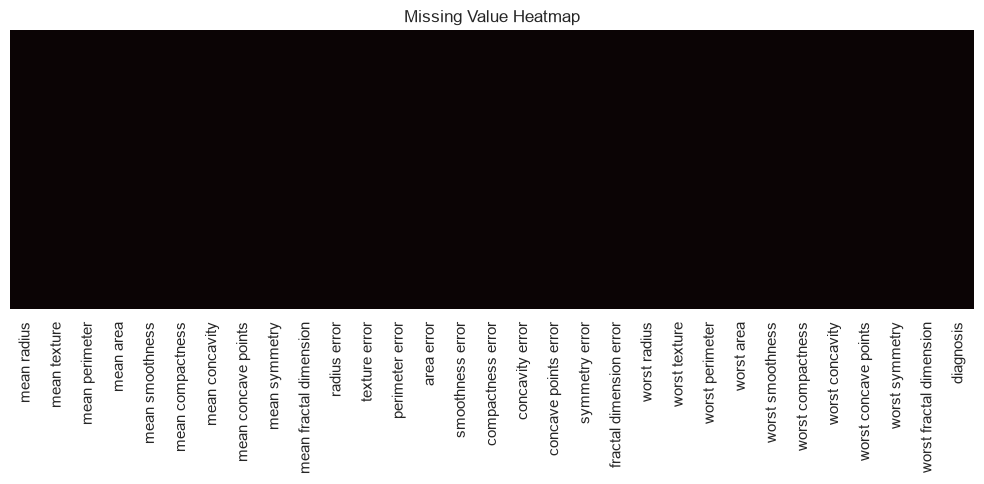

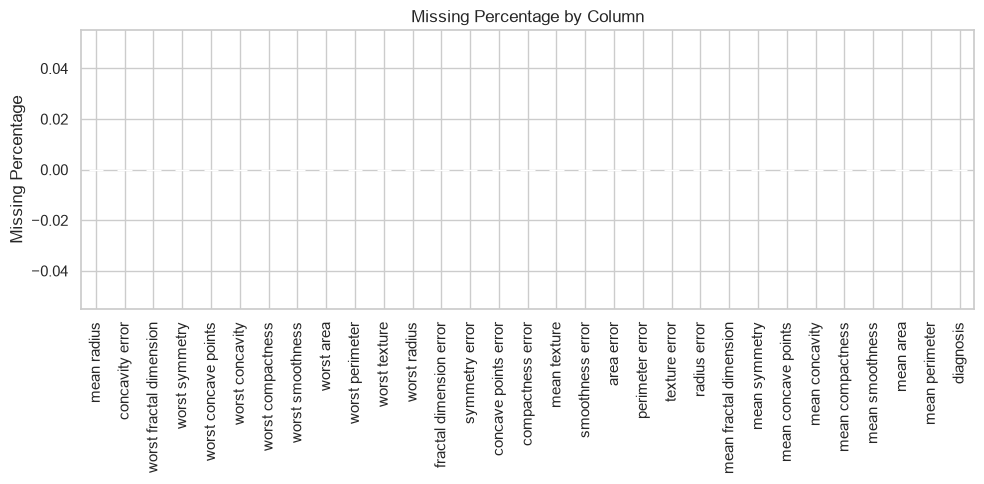

,column,missing_%
0,mean radius,0.0
1,concavity error,0.0
2,worst fractal dimension,0.0
3,worst symmetry,0.0
4,worst concave points,0.0
5,worst concavity,0.0
6,worst compactness,0.0
7,worst smoothness,0.0
8,worst area,0.0
9,worst perimeter,0.0


,feature,iqr_lower,iqr_upper,iqr_outliers,z_score_outliers
0,mean radius,5.5800,21.9000,14,5
1,mean texture,7.7250,30.2450,7,4
2,mean perimeter,31.7750,147.4950,13,7
3,mean area,-123.3000,1326.3000,25,8
4,mean smoothness,0.0580,0.1337,6,5
5,mean compactness,-0.0333,0.2286,16,9
6,mean concavity,-0.1222,0.2824,18,9
7,mean concave points,-0.0602,0.1545,10,6
8,mean symmetry,0.1112,0.2464,15,5
9,mean fractal dimension,0.0451,0.0787,15,7


mean radius: IQR=14, Z-score=5
mean texture: IQR=7, Z-score=4
mean perimeter: IQR=13, Z-score=7
mean area: IQR=25, Z-score=8
mean smoothness: IQR=6, Z-score=5
mean compactness: IQR=16, Z-score=9
mean concavity: IQR=18, Z-score=9
mean concave points: IQR=10, Z-score=6
mean symmetry: IQR=15, Z-score=5
mean fractal dimension: IQR=15, Z-score=7
radius error: IQR=38, Z-score=7
texture error: IQR=20, Z-score=9
perimeter error: IQR=38, Z-score=8
area error: IQR=65, Z-score=6
smoothness error: IQR=30, Z-score=7
compactness error: IQR=28, Z-score=12
concavity error: IQR=22, Z-score=6
concave points error: IQR=19, Z-score=6
symmetry error: IQR=27, Z-score=11
fractal dimension error: IQR=28, Z-score=10
worst radius: IQR=17, Z-score=6
worst texture: IQR=5, Z-score=4
worst perimeter: IQR=15, Z-score=6
worst area: IQR=35, Z-score=10
worst smoothness: IQR=7, Z-score=3
worst compactness: IQR=16, Z-score=10
worst concavity: IQR=12, Z-score=7
worst concave points: IQR=0, Z-score=0
worst symmetry: IQR=23

,feature,test,statistic,p_value,normal
0,mean radius,Shapiro,0.9411,3.1056e-14,False
1,mean texture,Shapiro,0.9767,7.2836e-08,False
2,mean perimeter,Shapiro,0.9362,7.0114e-15,False
3,mean area,Shapiro,0.8584,3.1963e-22,False
4,mean smoothness,Shapiro,0.9875,8.6008e-05,False
5,mean compactness,Shapiro,0.9170,3.9672e-17,False
6,mean concavity,Shapiro,0.8668,1.3386e-21,False
7,mean concave points,Shapiro,0.8917,1.4046e-19,False
8,mean symmetry,Shapiro,0.9726,7.8848e-09,False
9,mean fractal dimension,Shapiro,0.9233,1.9566e-16,False


,feature,test,statistic,p_value
0,mean radius,ANOVA,646.9810,8.4659e-96
1,mean texture,ANOVA,118.0961,4.0586e-25
2,mean perimeter,ANOVA,697.2353,8.4363e-101
3,mean area,ANOVA,573.0607,4.7346e-88
4,mean smoothness,ANOVA,83.6511,1.0519e-18
5,mean compactness,ANOVA,313.2331,3.9383e-56
6,mean concavity,ANOVA,533.7931,9.9666e-84
7,mean concave points,ANOVA,861.6760,7.1012e-116
8,mean symmetry,ANOVA,69.5274,5.7334e-16
9,mean fractal dimension,ANOVA,0.0935,7.5994e-01


**Pearson Correlation Matrix**

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.0000,0.3238,0.9979,0.9874,0.1706,0.5061,0.6768,0.8225,0.1477,-0.3116,...,0.9695,0.2970,0.9651,0.9411,0.1196,0.4135,0.5269,0.7442,0.1640,0.0071
mean texture,0.3238,1.0000,0.3295,0.3211,-0.0234,0.2367,0.3024,0.2935,0.0714,-0.0764,...,0.3526,0.9120,0.3580,0.3435,0.0775,0.2778,0.3010,0.2953,0.1050,0.1192
mean perimeter,0.9979,0.3295,1.0000,0.9865,0.2073,0.5569,0.7161,0.8510,0.1830,-0.2615,...,0.9695,0.3030,0.9704,0.9415,0.1505,0.4558,0.5639,0.7712,0.1891,0.0510
mean area,0.9874,0.3211,0.9865,1.0000,0.1770,0.4985,0.6860,0.8233,0.1513,-0.2831,...,0.9627,0.2875,0.9591,0.9592,0.1235,0.3904,0.5126,0.7220,0.1436,0.0037
mean smoothness,0.1706,-0.0234,0.2073,0.1770,1.0000,0.6591,0.5220,0.5537,0.5578,0.5848,...,0.2131,0.0361,0.2389,0.2067,0.8053,0.4725,0.4349,0.5031,0.3943,0.4993
mean compactness,0.5061,0.2367,0.5569,0.4985,0.6591,1.0000,0.8831,0.8311,0.6026,0.5654,...,0.5353,0.2481,0.5902,0.5096,0.5655,0.8658,0.8163,0.8156,0.5102,0.6874
mean concavity,0.6768,0.3024,0.7161,0.6860,0.5220,0.8831,1.0000,0.9214,0.5007,0.3368,...,0.6882,0.2999,0.7296,0.6760,0.4488,0.7550,0.8841,0.8613,0.4095,0.5149
mean concave points,0.8225,0.2935,0.8510,0.8233,0.5537,0.8311,0.9214,1.0000,0.4625,0.1669,...,0.8303,0.2928,0.8559,0.8096,0.4528,0.6675,0.7524,0.9102,0.3757,0.3687
mean symmetry,0.1477,0.0714,0.1830,0.1513,0.5578,0.6026,0.5007,0.4625,1.0000,0.4799,...,0.1857,0.0907,0.2192,0.1772,0.4267,0.4732,0.4337,0.4303,0.6998,0.4384
mean fractal dimension,-0.3116,-0.0764,-0.2615,-0.2831,0.5848,0.5654,0.3368,0.1669,0.4799,1.0000,...,-0.2537,-0.0513,-0.2052,-0.2319,0.5049,0.4588,0.3462,0.1753,0.3340,0.7673


**Spearman Correlation Matrix**

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.0000,0.3410,0.9978,0.9996,0.1485,0.4976,0.6457,0.7597,0.1202,-0.3499,...,0.9786,0.3149,0.9716,0.9789,0.1258,0.4914,0.5960,0.7273,0.1747,0.0446
mean texture,0.3410,1.0000,0.3481,0.3441,0.0246,0.2665,0.3426,0.3069,0.1101,-0.0593,...,0.3665,0.9092,0.3753,0.3683,0.1014,0.2909,0.3397,0.3192,0.1207,0.1161
mean perimeter,0.9978,0.3481,1.0000,0.9971,0.1829,0.5439,0.6820,0.7886,0.1500,-0.3049,...,0.9812,0.3231,0.9790,0.9809,0.1566,0.5346,0.6321,0.7575,0.1990,0.0890
mean area,0.9996,0.3441,0.9971,1.0000,0.1381,0.4890,0.6426,0.7552,0.1139,-0.3584,...,0.9793,0.3182,0.9718,0.9803,0.1197,0.4858,0.5937,0.7234,0.1709,0.0388
mean smoothness,0.1485,0.0246,0.1829,0.1381,1.0000,0.6788,0.5185,0.5652,0.5422,0.5885,...,0.2035,0.0606,0.2263,0.1917,0.7961,0.4814,0.4291,0.4989,0.3936,0.5115
mean compactness,0.4976,0.2665,0.5439,0.4890,0.6788,1.0000,0.8965,0.8483,0.5522,0.4992,...,0.5426,0.2553,0.5923,0.5316,0.5789,0.9010,0.8379,0.8255,0.4503,0.6890
mean concavity,0.6457,0.3426,0.6820,0.6426,0.5185,0.8965,1.0000,0.9274,0.4468,0.2582,...,0.6823,0.3359,0.7224,0.6766,0.4888,0.8500,0.9385,0.9049,0.3837,0.5418
mean concave points,0.7597,0.3069,0.7886,0.7552,0.5652,0.8483,0.9274,1.0000,0.4238,0.1427,...,0.7874,0.3006,0.8140,0.7804,0.4900,0.7583,0.8273,0.9371,0.3555,0.4211
mean symmetry,0.1202,0.1101,0.1500,0.1139,0.5422,0.5522,0.4468,0.4238,1.0000,0.4285,...,0.1646,0.1189,0.1905,0.1545,0.4242,0.4408,0.3945,0.3975,0.7104,0.4101
mean fractal dimension,-0.3499,-0.0593,-0.3049,-0.3584,0.5885,0.4992,0.2582,0.1427,0.4285,1.0000,...,-0.2945,-0.0478,-0.2475,-0.3049,0.4935,0.4037,0.2426,0.1392,0.2950,0.7608


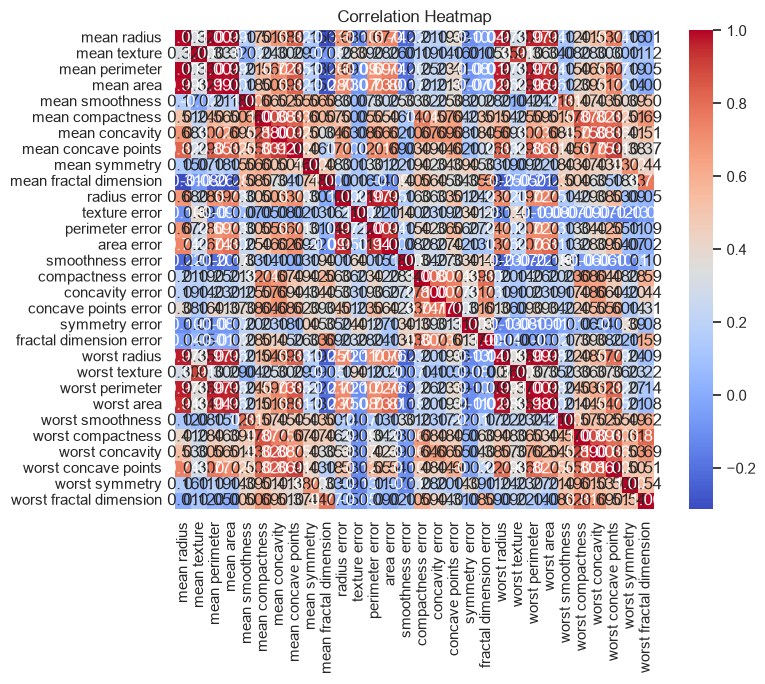

Highly correlated pairs: 44


,feature_1,feature_2,correlation
0,mean radius,mean perimeter,0.9979
1,mean radius,mean area,0.9874
2,mean radius,mean concave points,0.8225
3,mean radius,worst radius,0.9695
4,mean radius,worst perimeter,0.9651
5,mean radius,worst area,0.9411
6,mean texture,worst texture,0.9120
7,mean perimeter,mean area,0.9865
8,mean perimeter,mean concave points,0.8510
9,mean perimeter,worst radius,0.9695


,diagnosis,count
0,B,357
1,M,212


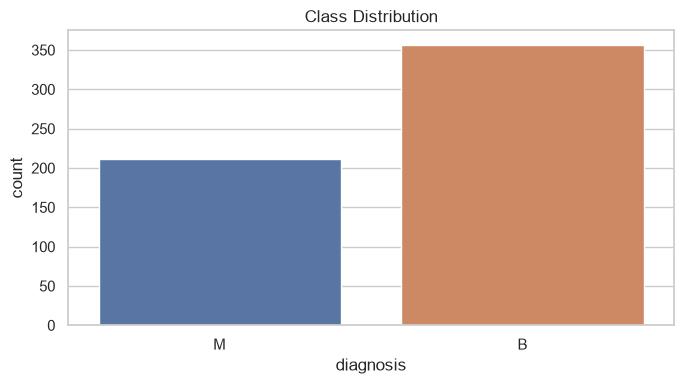

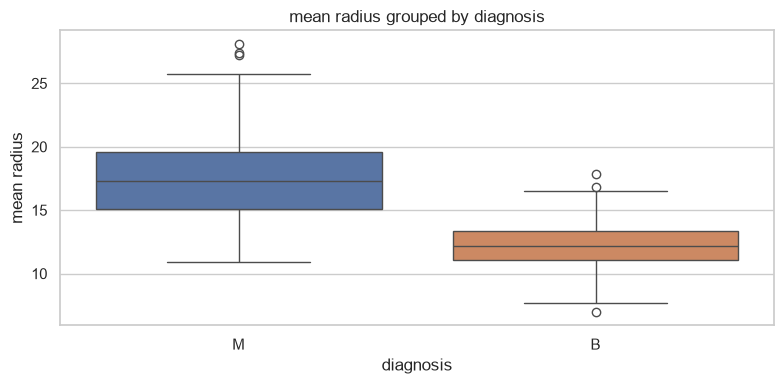

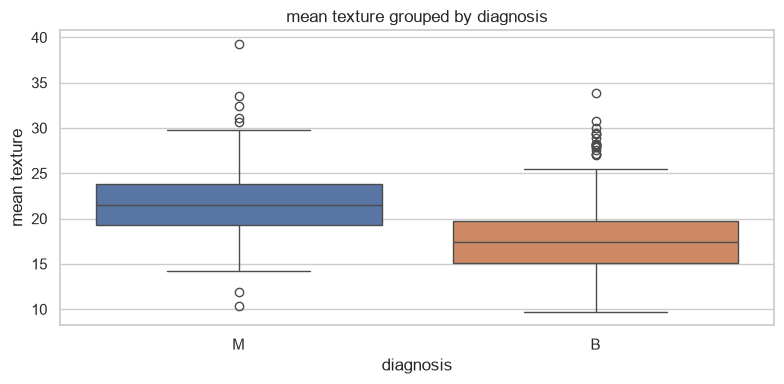

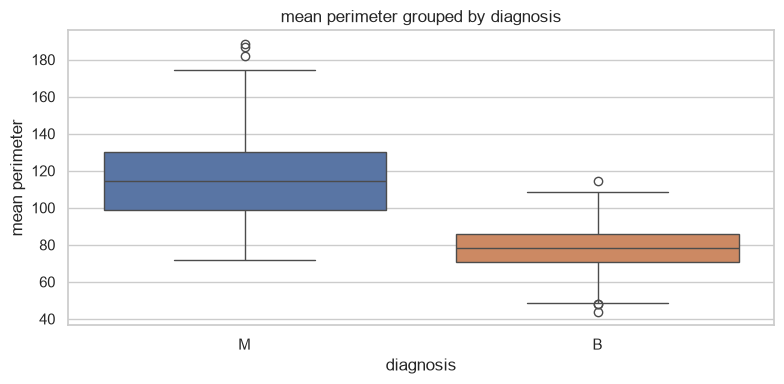

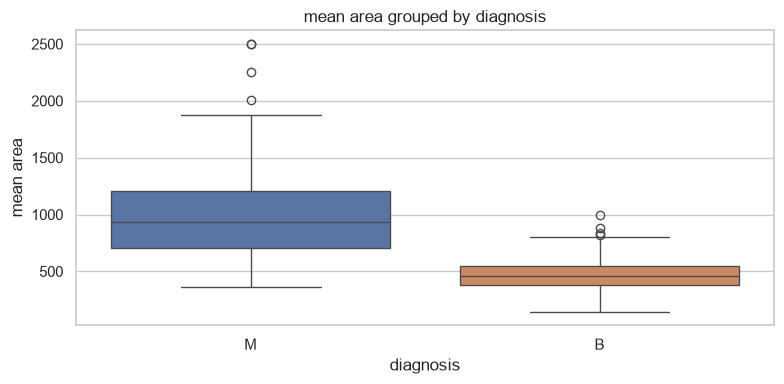

Training shape: (455, 30)
Testing shape: (114, 30)
Encoded features: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
10,0.5186,0.8918,0.4246,0.3839,-0.9747,-0.6898,-0.6886,-0.3982,-1.0392,-0.8251,...,0.5798,1.3132,0.4669,0.4460,-0.5962,-0.6347,-0.6102,-0.2357,0.0546,0.0218
170,-0.5164,-1.6397,-0.5413,-0.5430,0.4762,-0.6318,-0.6043,-0.3031,0.5215,-0.4545,...,-0.5825,-1.6903,-0.6119,-0.5870,0.2736,-0.8148,-0.7127,-0.3232,-0.1376,-0.9044
407,-0.3681,0.4555,-0.3882,-0.4030,-1.4330,-0.3839,-0.3422,-0.7655,-0.8509,-0.2262,...,-0.3986,0.1820,-0.4754,-0.4208,-1.6228,-0.3914,-0.4313,-0.8908,-0.6759,-0.1440
430,0.2053,0.7262,0.4003,0.0706,0.2433,2.2036,2.2561,1.2132,0.8185,0.8998,...,-0.0003,0.2742,0.5138,-0.0995,0.4185,2.8660,2.9586,1.9771,-0.0756,1.7288
27,1.2430,0.1942,1.2104,1.2067,-0.1114,0.0513,0.7330,0.7138,-0.4272,-0.8222,...,1.0128,0.2231,0.9385,0.8809,0.0732,-0.2770,0.3278,0.5019,-0.9093,-0.5462


,feature,select_k_best_score,p_value,mutual_information
20,worst radius,692.8614,2.4837e-93,0.4612
22,worst perimeter,717.2465,2.0930e-95,0.4546
23,worst area,522.1889,1.9324e-77,0.4533
7,mean concave points,684.5268,1.3009e-92,0.4460
27,worst concave points,733.7249,8.7786e-97,0.4329
2,mean perimeter,548.4132,4.6875e-80,0.4093
3,mean area,444.8575,2.6912e-69,0.3747
0,mean radius,511.2748,2.4851e-76,0.3733
6,mean concavity,397.5921,5.7819e-64,0.3541
13,area error,180.5612,6.9984e-35,0.3500


,component,explained_variance_ratio
0,PC1,0.4459
1,PC2,0.1855


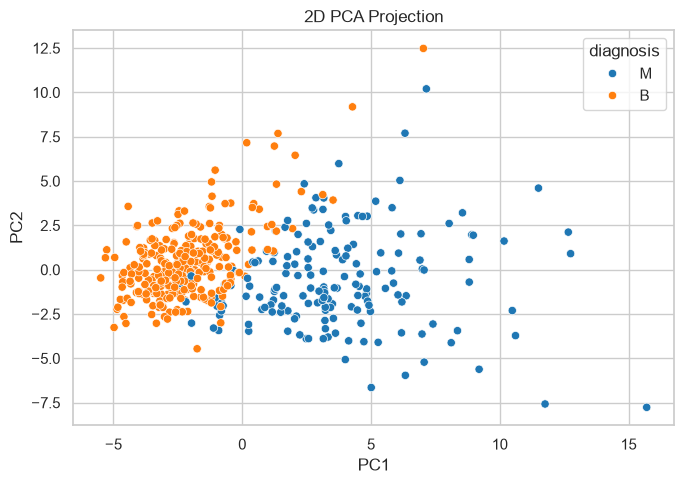

Dataset contains 569 samples and 31 columns.
Detected 30 numerical features and 0 categorical features.
Target column `diagnosis` is treated as Categorical; task type is classification.
Duplicate rows: 0.
Columns with missing values: 0.
Highly correlated feature pairs: 44.
Constant features: None.
Suggested models: Logistic Regression, Decision Tree, Random Forest, KNN, Naive Bayes, SVM.
Report saved to: experiment6_output/eda_reuse/eda_report.md
Plots saved to: experiment6_output/eda_reuse/plots


In [7]:
%run $EDA_NOTEBOOK_PATH

## Receive Processed Dataset

In [8]:
assert problem_type == "classification", "Experiment 6 requires a classification dataset."
assert TARGET_COLUMN == "diagnosis", "Experiment 6 expects the target column to be named 'diagnosis'."

required_variables = ["X_train", "X_test", "y_train", "y_test", "feature_names", "preprocessor", "problem_type"]
missing_variables = [name for name in required_variables if name not in globals()]
assert not missing_variables, f"Missing variables from EDA notebook: {missing_variables}"

classes = np.array(sorted(pd.Series(y_train).dropna().unique()))
assert len(classes) == 2, f"This notebook is designed for binary classification, found classes: {classes}"
positive_label = classes[-1]
negative_label = classes[0]

experiment_rows = []
model_store = {}
classification_reports = {}
plot_registry = []


def sanitize_filename(name: str) -> str:
    cleaned = re.sub(r"[^a-zA-Z0-9]+", "_", name).strip("_").lower()
    return cleaned or "plot"


def save_current_plot(filename: str):
    output_path = os.path.join(PLOTS_DIRECTORY, filename)
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight", dpi=160)
    plot_registry.append(output_path)
    plt.show()


def measure_execution_time(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    elapsed = time.perf_counter() - start
    return result, elapsed


def predict_scores(model, features):
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(features)
        return probabilities[:, 1] if probabilities.ndim == 2 else probabilities
    if hasattr(model, "decision_function"):
        return model.decision_function(features)
    return None


def metric_dict(y_true, y_pred, y_score=None):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "ROC-AUC": np.nan,
    }
    if y_score is not None:
        encoded_true = (pd.Series(y_true).to_numpy() == positive_label).astype(int)
        metrics["ROC-AUC"] = roc_auc_score(encoded_true, y_score)
    return metrics


def plot_confusion_matrix(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(5.2, 4.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    save_current_plot(f"confusion_matrix_{sanitize_filename(model_name)}.png")


def plot_roc_curve(model_name, y_true, y_score):
    if y_score is None:
        return
    encoded_true = (pd.Series(y_true).to_numpy() == positive_label).astype(int)
    fpr, tpr, _ = roc_curve(encoded_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 4.2))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)
    plt.title(f"ROC Curve - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    save_current_plot(f"roc_curve_{sanitize_filename(model_name)}.png")


def store_results(model_name, metrics, training_time, prediction_time, extra=None):
    payload = {
        "Model": model_name,
        **metrics,
        "Training Time": training_time,
        "Prediction Time": prediction_time,
    }
    if extra:
        payload.update(extra)
    experiment_rows.append(payload)
    return payload


def train_and_evaluate_model(model_name, estimator, plot=True, extra=None):
    model = clone(estimator)
    _, training_time = measure_execution_time(model.fit, X_train, y_train)
    predictions, prediction_time = measure_execution_time(model.predict, X_test)
    scores = predict_scores(model, X_test)
    metrics = metric_dict(y_test, predictions, scores)
    row = store_results(model_name, metrics, training_time, prediction_time, extra=extra)
    model_store[model_name] = model
    report_df = pd.DataFrame(classification_report(y_test, predictions, output_dict=True, zero_division=0)).transpose()
    classification_reports[model_name] = report_df

    display(pd.DataFrame([row]))
    display(report_df)
    if plot:
        plot_confusion_matrix(model_name, y_test, predictions)
        plot_roc_curve(model_name, y_test, scores)
    return model, row, report_df


display(Markdown("**Processed dataset received from EDA**"))
summary_table = pd.DataFrame({
    "Artifact": ["X_train", "X_test", "y_train", "y_test", "Feature Count", "Positive Label", "Negative Label"],
    "Value": [X_train.shape, X_test.shape, y_train.shape, y_test.shape, len(feature_names), positive_label, negative_label],
})
display(summary_table)
display(pd.Series(y_train).value_counts().rename_axis(TARGET_COLUMN).reset_index(name="train_count"))


**Processed dataset received from EDA**

,Artifact,Value
0,X_train,"(455, 30)"
1,X_test,"(114, 30)"
2,y_train,"(455,)"
3,y_test,"(114,)"
4,Feature Count,30
5,Positive Label,M
6,Negative Label,B


,diagnosis,train_count
0,B,285
1,M,170


## Baseline Decision Tree (Reference Model)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Single Decision Tree,0.9298,0.9048,0.9048,0.9048,0.9246,0.0036,0.0003


,precision,recall,f1-score,support
B,0.9444,0.9444,0.9444,72.0000
M,0.9048,0.9048,0.9048,42.0000
accuracy,0.9298,0.9298,0.9298,0.9298
macro avg,0.9246,0.9246,0.9246,114.0000
weighted avg,0.9298,0.9298,0.9298,114.0000


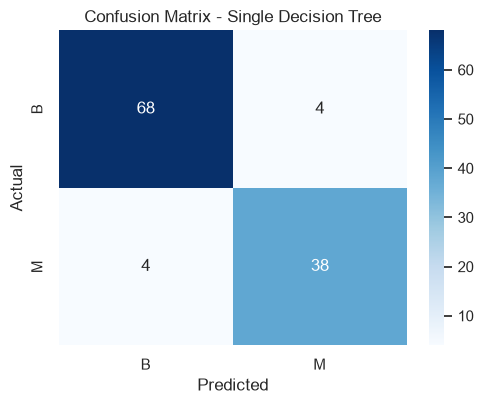

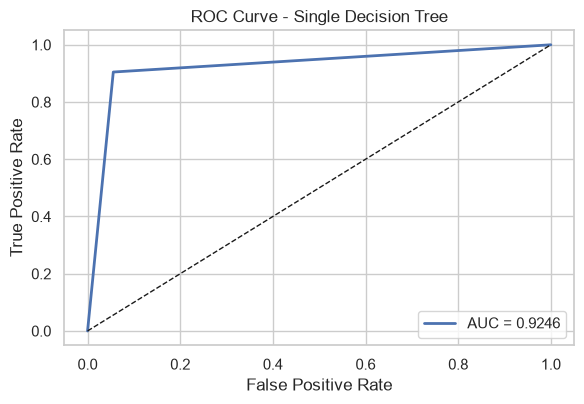

Single Decision Tree 5-fold CV accuracy: mean=0.9231, std=0.0326


In [9]:
baseline_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_tree_model, baseline_tree_result, baseline_tree_report = train_and_evaluate_model("Single Decision Tree", baseline_tree)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_scorer = make_scorer(f1_score, pos_label=positive_label)

baseline_tree_cv_scores = cross_val_score(clone(baseline_tree), X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
print(f"Single Decision Tree 5-fold CV accuracy: mean={baseline_tree_cv_scores.mean():.4f}, std={baseline_tree_cv_scores.std():.4f}")


## Bagging Classifier

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Bagging,0.9649,1.0,0.9048,0.95,0.9767,0.0192,0.001


,precision,recall,f1-score,support
B,0.9474,1.0000,0.9730,72.0000
M,1.0000,0.9048,0.9500,42.0000
accuracy,0.9649,0.9649,0.9649,0.9649
macro avg,0.9737,0.9524,0.9615,114.0000
weighted avg,0.9668,0.9649,0.9645,114.0000


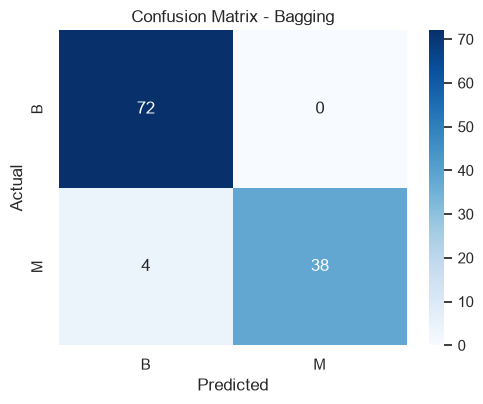

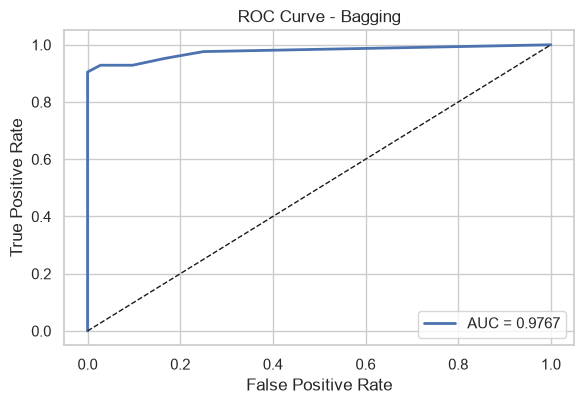

Bagging (baseline) 5-fold CV accuracy: mean=0.9604, std=0.0192


In [10]:
bagging_baseline = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE), random_state=RANDOM_STATE)
bagging_model, bagging_result, bagging_report = train_and_evaluate_model("Bagging", bagging_baseline)

bagging_baseline_cv_scores = cross_val_score(clone(bagging_baseline), X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
print(f"Bagging (baseline) 5-fold CV accuracy: mean={bagging_baseline_cv_scores.mean():.4f}, std={bagging_baseline_cv_scores.std():.4f}")


## Bagging Hyperparameter Tuning

,Model,Search Method,Best Parameters,Best CV Accuracy,Execution Time
0,Bagging,GridSearchCV,"{'max_features': 0.5, 'max_samples': 0.7, 'n_estimators': 50}",0.9736,2.2576


,n_estimators,max_samples,Avg CV Accuracy (%),Avg CV F1 Score
0,50,0.7,97.36,0.9643
1,50,1.0,96.92,0.9583
2,50,0.5,96.70,0.9542
3,100,0.7,96.70,0.9547
4,100,1.0,96.70,0.9551
5,200,1.0,96.70,0.9551
6,200,0.7,96.48,0.9519
7,10,0.5,96.26,0.9477
8,10,0.7,96.26,0.9486
9,100,0.5,96.26,0.9487


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Bagging (Tuned),0.9649,1.0,0.9048,0.95,0.9917,0.042,0.0017


,precision,recall,f1-score,support
B,0.9474,1.0000,0.9730,72.0000
M,1.0000,0.9048,0.9500,42.0000
accuracy,0.9649,0.9649,0.9649,0.9649
macro avg,0.9737,0.9524,0.9615,114.0000
weighted avg,0.9668,0.9649,0.9645,114.0000


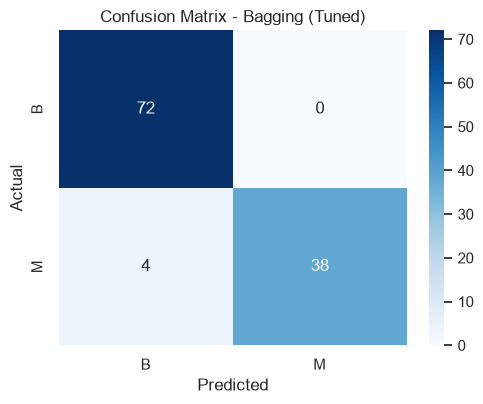

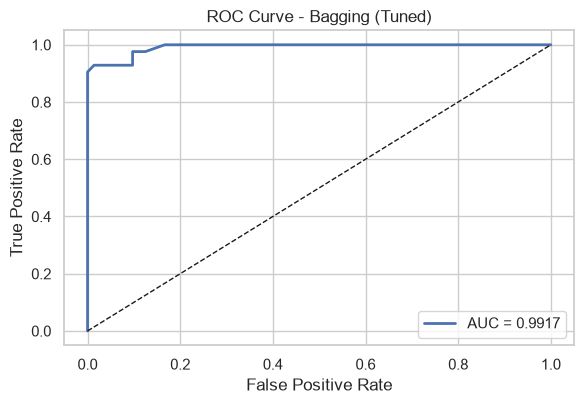

Bagging (Tuned) 5-fold CV accuracy: mean=0.9736, std=0.0192


In [11]:
bagging_param_grid = {
    "n_estimators": [10, 50, 100, 200],
    "max_samples": [0.5, 0.7, 1.0],
    "max_features": [0.5, 0.7, 1.0],
}

bagging_grid_search = GridSearchCV(
    estimator=BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE), random_state=RANDOM_STATE),
    param_grid=bagging_param_grid,
    scoring={"accuracy": "accuracy", "f1": f1_scorer},
    refit="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

_, bagging_tuning_time = measure_execution_time(bagging_grid_search.fit, X_train, y_train)
bagging_cv_results = pd.DataFrame(bagging_grid_search.cv_results_)
bagging_best_params = bagging_grid_search.best_params_
bagging_best_cv_accuracy = bagging_grid_search.best_score_

display(pd.DataFrame([
    {
        "Model": "Bagging",
        "Search Method": "GridSearchCV",
        "Best Parameters": str(bagging_best_params),
        "Best CV Accuracy": bagging_best_cv_accuracy,
        "Execution Time": bagging_tuning_time,
    }
]))

bagging_grouped = bagging_cv_results.sort_values("mean_test_accuracy", ascending=False).groupby(
    ["param_n_estimators", "param_max_samples"], as_index=False
).first()
bagging_hyperparameter_table = bagging_grouped[["param_n_estimators", "param_max_samples", "mean_test_accuracy", "mean_test_f1"]].copy()
bagging_hyperparameter_table.columns = ["n_estimators", "max_samples", "Avg CV Accuracy (%)", "Avg CV F1 Score"]
bagging_hyperparameter_table["Avg CV Accuracy (%)"] = (bagging_hyperparameter_table["Avg CV Accuracy (%)"] * 100).round(2)
bagging_hyperparameter_table["Avg CV F1 Score"] = bagging_hyperparameter_table["Avg CV F1 Score"].round(4)
bagging_hyperparameter_table = bagging_hyperparameter_table.sort_values("Avg CV Accuracy (%)", ascending=False).reset_index(drop=True)
display(bagging_hyperparameter_table)

tuned_bagging_model, tuned_bagging_result, tuned_bagging_report = train_and_evaluate_model(
    "Bagging (Tuned)",
    bagging_grid_search.best_estimator_,
)

tuned_bagging_cv_scores = cross_val_score(clone(bagging_grid_search.best_estimator_), X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
print(f"Bagging (Tuned) 5-fold CV accuracy: mean={tuned_bagging_cv_scores.mean():.4f}, std={tuned_bagging_cv_scores.std():.4f}")


## Boosting Classifiers

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,AdaBoost,0.9825,1.0,0.9524,0.9756,0.9841,0.0473,0.0019


,precision,recall,f1-score,support
B,0.9730,1.0000,0.9863,72.0000
M,1.0000,0.9524,0.9756,42.0000
accuracy,0.9825,0.9825,0.9825,0.9825
macro avg,0.9865,0.9762,0.9810,114.0000
weighted avg,0.9829,0.9825,0.9824,114.0000


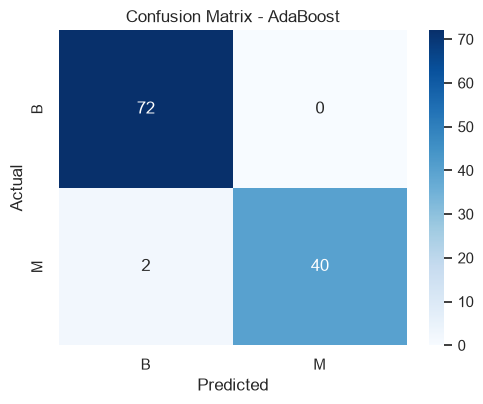

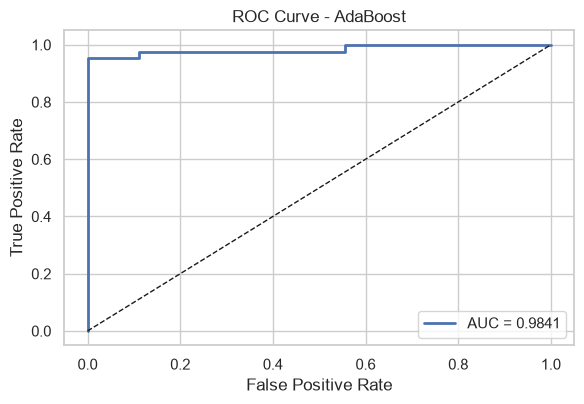

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Gradient Boosting,0.9649,1.0,0.9048,0.95,0.9947,0.1306,0.0006


,precision,recall,f1-score,support
B,0.9474,1.0000,0.9730,72.0000
M,1.0000,0.9048,0.9500,42.0000
accuracy,0.9649,0.9649,0.9649,0.9649
macro avg,0.9737,0.9524,0.9615,114.0000
weighted avg,0.9668,0.9649,0.9645,114.0000


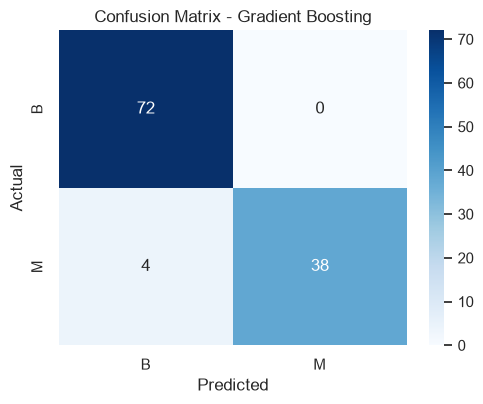

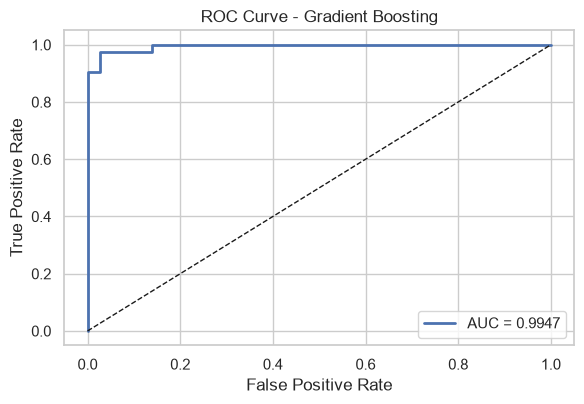

In [12]:
adaboost_baseline = AdaBoostClassifier(random_state=RANDOM_STATE)
adaboost_model, adaboost_result, adaboost_report = train_and_evaluate_model("AdaBoost", adaboost_baseline)

gradient_boosting_baseline = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_model, gb_result, gb_report = train_and_evaluate_model("Gradient Boosting", gradient_boosting_baseline)


## Boosting Hyperparameter Tuning

,Algorithm,n_estimators,learning_rate,max_depth,Avg CV Accuracy (%),Avg CV F1 Score
0,Gradient Boosting,200,0.10,2,97.36,0.9645
1,AdaBoost,200,1.00,-,97.14,0.9610
2,AdaBoost,100,0.50,-,97.14,0.9607
3,AdaBoost,200,0.50,-,97.14,0.9612
4,Gradient Boosting,200,0.50,2,96.92,0.9578
5,Gradient Boosting,200,0.10,4,96.92,0.9584
6,Gradient Boosting,200,0.10,3,96.92,0.9582
7,Gradient Boosting,50,0.50,3,96.70,0.9546
8,Gradient Boosting,100,0.10,2,96.70,0.9551
9,Gradient Boosting,100,0.10,3,96.70,0.9553


**Boosting winner selected for the tuned comparison: Gradient Boosting** (CV accuracy AdaBoost=0.9714, Gradient Boosting=0.9736)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Boosting (Tuned),0.9649,1.0,0.9048,0.95,0.9934,0.1857,0.0007


,precision,recall,f1-score,support
B,0.9474,1.0000,0.9730,72.0000
M,1.0000,0.9048,0.9500,42.0000
accuracy,0.9649,0.9649,0.9649,0.9649
macro avg,0.9737,0.9524,0.9615,114.0000
weighted avg,0.9668,0.9649,0.9645,114.0000


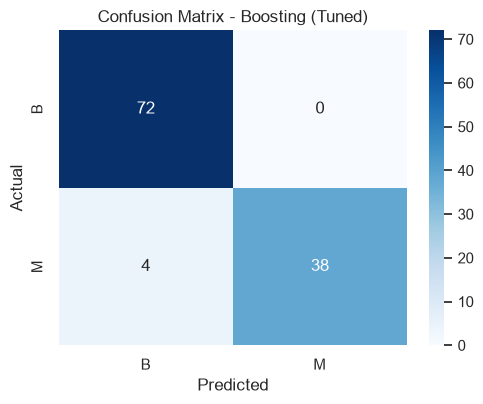

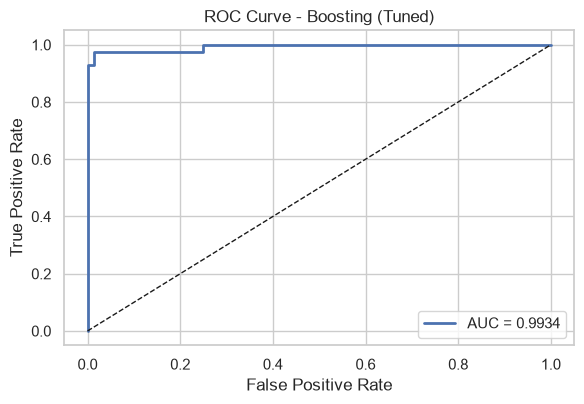

Boosting (Tuned) [Gradient Boosting] 5-fold CV accuracy: mean=0.9736, std=0.0088


In [13]:
adaboost_param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.5, 1.0],
}
adaboost_grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=RANDOM_STATE),
    param_grid=adaboost_param_grid,
    scoring={"accuracy": "accuracy", "f1": f1_scorer},
    refit="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
_, adaboost_tuning_time = measure_execution_time(adaboost_grid_search.fit, X_train, y_train)
adaboost_cv_results = pd.DataFrame(adaboost_grid_search.cv_results_)

gb_param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.5],
    "max_depth": [2, 3, 4],
}
gb_grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_grid=gb_param_grid,
    scoring={"accuracy": "accuracy", "f1": f1_scorer},
    refit="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)
_, gb_tuning_time = measure_execution_time(gb_grid_search.fit, X_train, y_train)
gb_cv_results = pd.DataFrame(gb_grid_search.cv_results_)

adaboost_grouped = adaboost_cv_results.sort_values("mean_test_accuracy", ascending=False).groupby(
    ["param_n_estimators", "param_learning_rate"], as_index=False
).first()
adaboost_table = adaboost_grouped[["param_n_estimators", "param_learning_rate", "mean_test_accuracy", "mean_test_f1"]].copy()
adaboost_table.columns = ["n_estimators", "learning_rate", "Avg CV Accuracy (%)", "Avg CV F1 Score"]
adaboost_table.insert(0, "Algorithm", "AdaBoost")
adaboost_table.insert(3, "max_depth", "-")

gb_grouped = gb_cv_results.sort_values("mean_test_accuracy", ascending=False).groupby(
    ["param_n_estimators", "param_learning_rate", "param_max_depth"], as_index=False
).first()
gb_table = gb_grouped[["param_n_estimators", "param_learning_rate", "param_max_depth", "mean_test_accuracy", "mean_test_f1"]].copy()
gb_table.columns = ["n_estimators", "learning_rate", "max_depth", "Avg CV Accuracy (%)", "Avg CV F1 Score"]
gb_table.insert(0, "Algorithm", "Gradient Boosting")

boosting_hyperparameter_table = pd.concat([adaboost_table, gb_table], ignore_index=True)
boosting_hyperparameter_table["Avg CV Accuracy (%)"] = (boosting_hyperparameter_table["Avg CV Accuracy (%)"] * 100).round(2)
boosting_hyperparameter_table["Avg CV F1 Score"] = boosting_hyperparameter_table["Avg CV F1 Score"].round(4)
boosting_hyperparameter_table = boosting_hyperparameter_table.sort_values("Avg CV Accuracy (%)", ascending=False).reset_index(drop=True)
display(boosting_hyperparameter_table)

adaboost_best_cv_accuracy = adaboost_grid_search.best_score_
gb_best_cv_accuracy = gb_grid_search.best_score_

if gb_best_cv_accuracy >= adaboost_best_cv_accuracy:
    boosting_winner_name = "Gradient Boosting"
    boosting_best_estimator = gb_grid_search.best_estimator_
    boosting_best_params = gb_grid_search.best_params_
    boosting_best_cv_accuracy = gb_best_cv_accuracy
    boosting_tuning_time = gb_tuning_time
    boosting_cv_results = gb_cv_results
else:
    boosting_winner_name = "AdaBoost"
    boosting_best_estimator = adaboost_grid_search.best_estimator_
    boosting_best_params = adaboost_grid_search.best_params_
    boosting_best_cv_accuracy = adaboost_best_cv_accuracy
    boosting_tuning_time = adaboost_tuning_time
    boosting_cv_results = adaboost_cv_results

display(Markdown(f"**Boosting winner selected for the tuned comparison: {boosting_winner_name}** (CV accuracy AdaBoost={adaboost_best_cv_accuracy:.4f}, Gradient Boosting={gb_best_cv_accuracy:.4f})"))

tuned_boosting_model, tuned_boosting_result, tuned_boosting_report = train_and_evaluate_model(
    "Boosting (Tuned)",
    boosting_best_estimator,
)

tuned_boosting_cv_scores = cross_val_score(clone(boosting_best_estimator), X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
print(f"Boosting (Tuned) [{boosting_winner_name}] 5-fold CV accuracy: mean={tuned_boosting_cv_scores.mean():.4f}, std={tuned_boosting_cv_scores.std():.4f}")


## Stacked Ensemble

In [14]:
svm_base = SVC(probability=True, random_state=RANDOM_STATE)
nb_base = GaussianNB()
dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE)

svm_model, svm_result, svm_report = train_and_evaluate_model("SVM (Base Learner)", svm_base, plot=False)
nb_model, nb_result, nb_report = train_and_evaluate_model("Naive Bayes (Base Learner)", nb_base, plot=False)
dt_model, dt_result, dt_report = train_and_evaluate_model("Decision Tree (Base Learner)", dt_base, plot=False)

base_learner_summary = pd.DataFrame(experiment_rows)
base_learner_summary = base_learner_summary[base_learner_summary["Model"].isin(
    ["SVM (Base Learner)", "Naive Bayes (Base Learner)", "Decision Tree (Base Learner)"]
)][["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].reset_index(drop=True)
display(Markdown("**Individual base learner performance (for stacking diversity analysis)**"))
display(base_learner_summary)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,SVM (Base Learner),0.9737,1.0,0.9286,0.963,0.9947,0.0049,0.0006


,precision,recall,f1-score,support
B,0.9600,1.0000,0.9796,72.0000
M,1.0000,0.9286,0.9630,42.0000
accuracy,0.9737,0.9737,0.9737,0.9737
macro avg,0.9800,0.9643,0.9713,114.0000
weighted avg,0.9747,0.9737,0.9735,114.0000


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Naive Bayes (Base Learner),0.9211,0.9231,0.8571,0.8889,0.9891,0.001,0.0004


,precision,recall,f1-score,support
B,0.9200,0.9583,0.9388,72.0000
M,0.9231,0.8571,0.8889,42.0000
accuracy,0.9211,0.9211,0.9211,0.9211
macro avg,0.9215,0.9077,0.9138,114.0000
weighted avg,0.9211,0.9211,0.9204,114.0000


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Decision Tree (Base Learner),0.9298,0.9048,0.9048,0.9048,0.9246,0.0032,0.0002


,precision,recall,f1-score,support
B,0.9444,0.9444,0.9444,72.0000
M,0.9048,0.9048,0.9048,42.0000
accuracy,0.9298,0.9298,0.9298,0.9298
macro avg,0.9246,0.9246,0.9246,114.0000
weighted avg,0.9298,0.9298,0.9298,114.0000


**Individual base learner performance (for stacking diversity analysis)**

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM (Base Learner),0.9737,1.0000,0.9286,0.9630,0.9947
1,Naive Bayes (Base Learner),0.9211,0.9231,0.8571,0.8889,0.9891
2,Decision Tree (Base Learner),0.9298,0.9048,0.9048,0.9048,0.9246


## Stacked Ensemble Hyperparameter Search

,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
0,SVM + Naive Bayes + Decision Tree,Logistic Regression,97.36,0.9638
1,SVM + Decision Tree,Logistic Regression,97.14,0.9609
2,SVM + Naive Bayes,Logistic Regression,95.82,0.9433
3,Naive Bayes + Decision Tree,Logistic Regression,94.51,0.9244


**Best stacking configuration: SVM + Naive Bayes + Decision Tree + Logistic Regression** (CV accuracy = 0.9736)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Stacked Ensemble,0.9649,1.0,0.9048,0.95,0.997,0.0392,0.0013


,precision,recall,f1-score,support
B,0.9474,1.0000,0.9730,72.0000
M,1.0000,0.9048,0.9500,42.0000
accuracy,0.9649,0.9649,0.9649,0.9649
macro avg,0.9737,0.9524,0.9615,114.0000
weighted avg,0.9668,0.9649,0.9645,114.0000


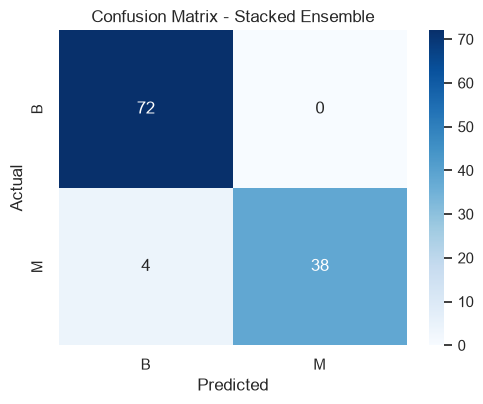

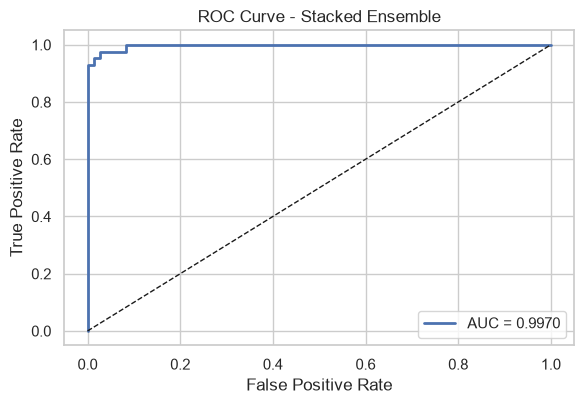

Stacked Ensemble 5-fold CV accuracy: mean=0.9736, std=0.0164


In [15]:
base_estimators_pool = {
    "svm": ("SVM", SVC(probability=True, random_state=RANDOM_STATE)),
    "nb": ("Naive Bayes", GaussianNB()),
    "dt": ("Decision Tree", DecisionTreeClassifier(random_state=RANDOM_STATE)),
}

stacking_combinations = [
    ["svm", "nb", "dt"],
    ["svm", "dt"],
    ["nb", "dt"],
    ["svm", "nb"],
]
meta_learners = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
}

stacking_search_rows = []
stacking_fitted_estimators = {}
for combo in stacking_combinations:
    for meta_name, meta_estimator in meta_learners.items():
        estimators = [(key, clone(base_estimators_pool[key][1])) for key in combo]
        stacking_clf = StackingClassifier(estimators=estimators, final_estimator=clone(meta_estimator), cv=cv, n_jobs=-1)
        scores = cross_validate(stacking_clf, X_train, y_train, cv=cv, scoring={"accuracy": "accuracy", "f1": f1_scorer}, n_jobs=-1)
        base_model_names = " + ".join(base_estimators_pool[key][0] for key in combo)
        stacking_search_rows.append({
            "Base Models": base_model_names,
            "Meta Learner": meta_name,
            "Avg CV Accuracy (%)": round(scores["test_accuracy"].mean() * 100, 2),
            "Avg CV F1 Score": round(scores["test_f1"].mean(), 4),
            "_combo": combo,
            "_meta_name": meta_name,
        })

stacking_search_table = pd.DataFrame(stacking_search_rows).sort_values("Avg CV Accuracy (%)", ascending=False).reset_index(drop=True)
stacked_ensemble_evaluation_table = stacking_search_table[["Base Models", "Meta Learner", "Avg CV Accuracy (%)", "Avg CV F1 Score"]]
display(stacked_ensemble_evaluation_table)

best_stacking_row = stacking_search_table.iloc[0]
best_combo = best_stacking_row["_combo"]
best_meta_name = best_stacking_row["_meta_name"]
best_estimators = [(key, clone(base_estimators_pool[key][1])) for key in best_combo]
best_stacking_estimator = StackingClassifier(
    estimators=best_estimators,
    final_estimator=clone(meta_learners[best_meta_name]),
    cv=cv,
    n_jobs=-1,
)
stacking_best_cv_accuracy = best_stacking_row["Avg CV Accuracy (%)"] / 100

display(Markdown(f"**Best stacking configuration: {best_stacking_row['Base Models']} + {best_meta_name}** (CV accuracy = {stacking_best_cv_accuracy:.4f})"))

stacked_model, stacked_result, stacked_report = train_and_evaluate_model("Stacked Ensemble", best_stacking_estimator)

stacking_cv_scores = cross_val_score(clone(best_stacking_estimator), X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
print(f"Stacked Ensemble 5-fold CV accuracy: mean={stacking_cv_scores.mean():.4f}, std={stacking_cv_scores.std():.4f}")


## Cross Validation

In [16]:
cv_table = pd.DataFrame({
    "Model": ["Bagging", "Boosting", "Stacked Ensemble"],
    "Fold 1": [tuned_bagging_cv_scores[0], tuned_boosting_cv_scores[0], stacking_cv_scores[0]],
    "Fold 2": [tuned_bagging_cv_scores[1], tuned_boosting_cv_scores[1], stacking_cv_scores[1]],
    "Fold 3": [tuned_bagging_cv_scores[2], tuned_boosting_cv_scores[2], stacking_cv_scores[2]],
    "Fold 4": [tuned_bagging_cv_scores[3], tuned_boosting_cv_scores[3], stacking_cv_scores[3]],
    "Fold 5": [tuned_bagging_cv_scores[4], tuned_boosting_cv_scores[4], stacking_cv_scores[4]],
    "Average": [tuned_bagging_cv_scores.mean(), tuned_boosting_cv_scores.mean(), stacking_cv_scores.mean()],
})
display(cv_table)


,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Bagging,0.967,1.000,0.967,0.9451,0.989,0.9736
1,Boosting,0.967,0.978,0.967,0.9670,0.989,0.9736
2,Stacked Ensemble,0.967,0.989,0.978,0.9451,0.989,0.9736


## Performance Comparison

In [17]:
results_df = pd.DataFrame(experiment_rows)
metric_columns = ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "Training Time", "Prediction Time"]

bagging_performance_table = results_df[results_df["Model"].isin(["Bagging", "Bagging (Tuned)"])][metric_columns].reset_index(drop=True)
boosting_performance_table = results_df[results_df["Model"].isin(["AdaBoost", "Gradient Boosting", "Boosting (Tuned)"])][metric_columns].reset_index(drop=True)

hyperparameter_tuning_summary = pd.DataFrame([
    {
        "Model": "Bagging",
        "Search Method": "GridSearchCV",
        "Best Parameters": str(bagging_best_params),
        "Best CV Accuracy": bagging_best_cv_accuracy,
        "Execution Time": bagging_tuning_time,
    },
    {
        "Model": f"Boosting ({boosting_winner_name})",
        "Search Method": "GridSearchCV",
        "Best Parameters": str(boosting_best_params),
        "Best CV Accuracy": boosting_best_cv_accuracy,
        "Execution Time": boosting_tuning_time,
    },
    {
        "Model": "Stacked Ensemble",
        "Search Method": "Cross-Validated Combination Search",
        "Best Parameters": f"{best_stacking_row['Base Models']} + {best_meta_name}",
        "Best CV Accuracy": stacking_best_cv_accuracy,
        "Execution Time": np.nan,
    },
])

final_comparison_table = results_df[results_df["Model"].isin(["Bagging (Tuned)", "Boosting (Tuned)", "Stacked Ensemble"])][metric_columns].reset_index(drop=True)
final_comparison_table = final_comparison_table.rename(columns={"Bagging (Tuned)": "Bagging", "Boosting (Tuned)": "Boosting"})
final_comparison_table["Model"] = final_comparison_table["Model"].replace({"Bagging (Tuned)": "Bagging", "Boosting (Tuned)": "Boosting"})

display(Markdown("### Bagging Performance"))
display(bagging_performance_table)

display(Markdown("### Boosting Performance"))
display(boosting_performance_table)

display(Markdown("### Hyperparameter Tuning Summary"))
display(hyperparameter_tuning_summary)

display(Markdown("### Cross Validation Results"))
display(cv_table)

display(Markdown("### Performance Comparison of Ensemble Models"))
display(final_comparison_table)


### Bagging Performance

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Bagging,0.9649,1.0,0.9048,0.95,0.9767,0.0192,0.0010
1,Bagging (Tuned),0.9649,1.0,0.9048,0.95,0.9917,0.0420,0.0017


### Boosting Performance

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,AdaBoost,0.9825,1.0,0.9524,0.9756,0.9841,0.0473,0.0019
1,Gradient Boosting,0.9649,1.0,0.9048,0.9500,0.9947,0.1306,0.0006
2,Boosting (Tuned),0.9649,1.0,0.9048,0.9500,0.9934,0.1857,0.0007


### Hyperparameter Tuning Summary

,Model,Search Method,Best Parameters,Best CV Accuracy,Execution Time
0,Bagging,GridSearchCV,"{'max_features': 0.5, 'max_samples': 0.7, 'n_estimators': 50}",0.9736,2.2576
1,Boosting (Gradient Boosting),GridSearchCV,"{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}",0.9736,1.3798
2,Stacked Ensemble,Cross-Validated Combination Search,SVM + Naive Bayes + Decision Tree + Logistic Regression,0.9736,NaN


### Cross Validation Results

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average
0,Bagging,0.967,1.000,0.967,0.9451,0.989,0.9736
1,Boosting,0.967,0.978,0.967,0.9670,0.989,0.9736
2,Stacked Ensemble,0.967,0.989,0.978,0.9451,0.989,0.9736


### Performance Comparison of Ensemble Models

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time,Prediction Time
0,Bagging,0.9649,1.0,0.9048,0.95,0.9917,0.0420,0.0017
1,Boosting,0.9649,1.0,0.9048,0.95,0.9934,0.1857,0.0007
2,Stacked Ensemble,0.9649,1.0,0.9048,0.95,0.9970,0.0392,0.0013


## Visualizations

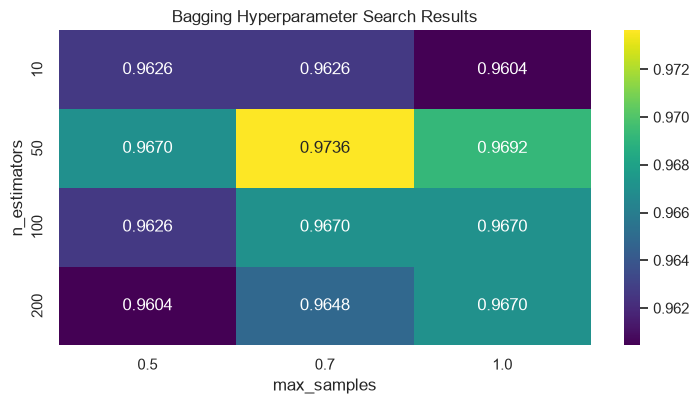

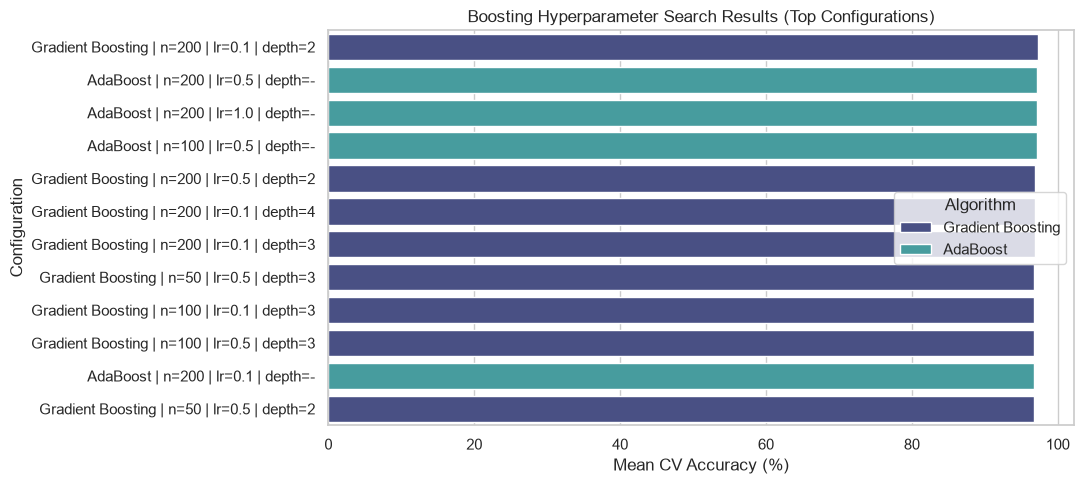

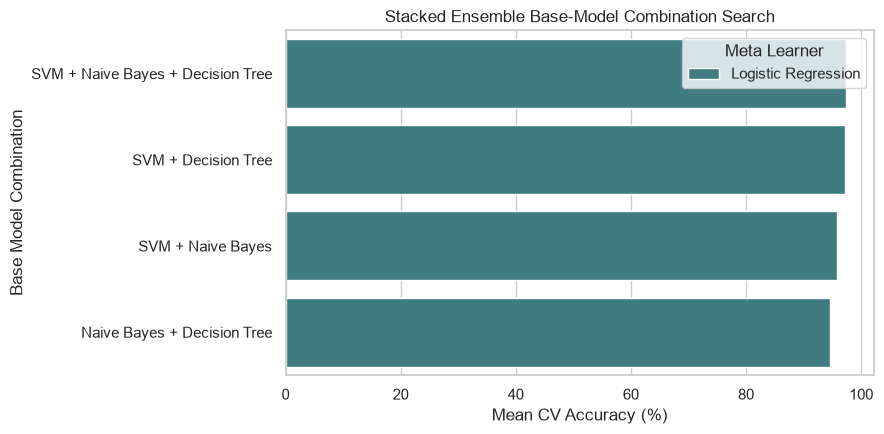

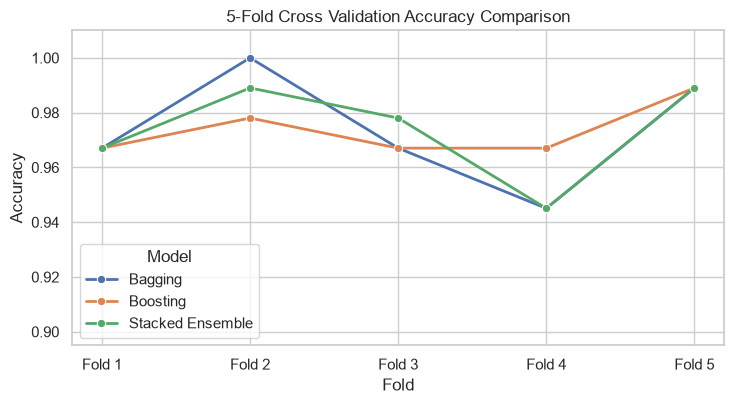

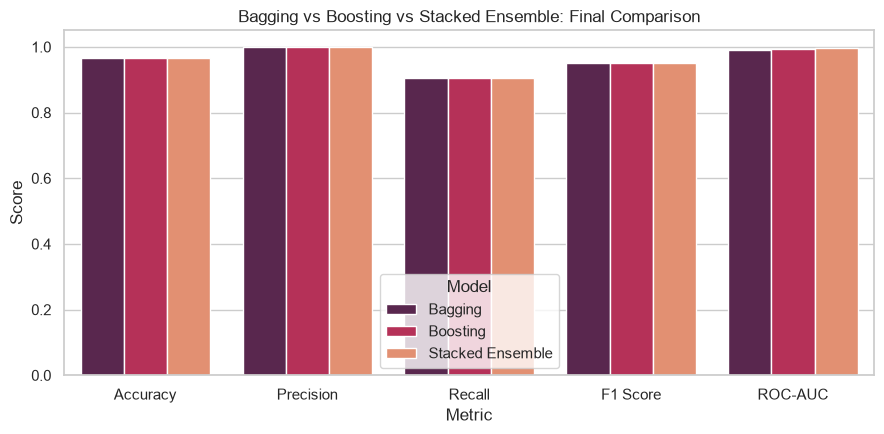

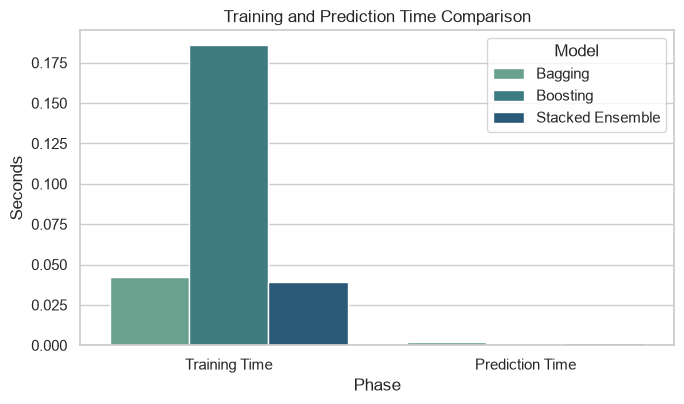

In [18]:
bagging_heatmap_data = bagging_cv_results.groupby(["param_n_estimators", "param_max_samples"])["mean_test_accuracy"].max().unstack()
plt.figure(figsize=(7.5, 4.2))
sns.heatmap(bagging_heatmap_data, annot=True, fmt=".4f", cmap="viridis")
plt.title("Bagging Hyperparameter Search Results")
plt.xlabel("max_samples")
plt.ylabel("n_estimators")
save_current_plot("bagging_hyperparameter_search_results.png")

boosting_plot_df = boosting_hyperparameter_table.copy()
boosting_plot_df["Configuration"] = boosting_plot_df.apply(
    lambda row: f"{row['Algorithm']} | n={row['n_estimators']} | lr={row['learning_rate']} | depth={row['max_depth']}",
    axis=1,
)
boosting_plot_df = boosting_plot_df.sort_values("Avg CV Accuracy (%)", ascending=False).head(12)
plt.figure(figsize=(11, 5))
sns.barplot(data=boosting_plot_df, x="Avg CV Accuracy (%)", y="Configuration", hue="Algorithm", dodge=False, palette="mako")
plt.title("Boosting Hyperparameter Search Results (Top Configurations)")
plt.xlabel("Mean CV Accuracy (%)")
plt.ylabel("Configuration")
save_current_plot("boosting_hyperparameter_search_results.png")

plt.figure(figsize=(9, 4.5))
sns.barplot(data=stacked_ensemble_evaluation_table, x="Avg CV Accuracy (%)", y="Base Models", hue="Meta Learner", dodge=False, palette="crest")
plt.title("Stacked Ensemble Base-Model Combination Search")
plt.xlabel("Mean CV Accuracy (%)")
plt.ylabel("Base Model Combination")
save_current_plot("stacking_combination_search_results.png")

cv_plot_df = cv_table.melt(id_vars="Model", value_vars=["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"], var_name="Fold", value_name="Accuracy")
plt.figure(figsize=(7.5, 4.2))
sns.lineplot(data=cv_plot_df, x="Fold", y="Accuracy", hue="Model", marker="o", linewidth=2)
plt.title("5-Fold Cross Validation Accuracy Comparison")
plt.ylim(max(0.7, cv_plot_df["Accuracy"].min() - 0.05), 1.01)
save_current_plot("cross_validation_accuracy_comparison.png")

comparison_plot_df = final_comparison_table.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    var_name="Metric",
    value_name="Score",
)
plt.figure(figsize=(9, 4.5))
sns.barplot(data=comparison_plot_df, x="Metric", y="Score", hue="Model", palette="rocket")
plt.title("Bagging vs Boosting vs Stacked Ensemble: Final Comparison")
plt.ylim(0, 1.05)
save_current_plot("ensemble_final_comparison.png")

time_plot_df = final_comparison_table.melt(
    id_vars="Model",
    value_vars=["Training Time", "Prediction Time"],
    var_name="Phase",
    value_name="Seconds",
)
plt.figure(figsize=(7, 4.2))
sns.barplot(data=time_plot_df, x="Phase", y="Seconds", hue="Model", palette="crest")
plt.title("Training and Prediction Time Comparison")
save_current_plot("time_comparison.png")


## Bias-Variance Analysis

In [19]:
bagging_variance_reduction = baseline_tree_cv_scores.std() - tuned_bagging_cv_scores.std()

single_weak_learner = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
weak_learner_cv_scores = cross_val_score(clone(single_weak_learner), X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
boosting_bias_reduction = tuned_boosting_cv_scores.mean() - weak_learner_cv_scores.mean()

best_base_learner_accuracy = base_learner_summary["Accuracy"].max()
stacking_gain_over_best_base = stacked_result["Accuracy"] - best_base_learner_accuracy

bias_variance_rows = [
    f"Bagging variance reduction: the single Decision Tree's 5-fold CV accuracy had a standard deviation of {baseline_tree_cv_scores.std():.4f}, while the tuned Bagging ensemble's standard deviation dropped to {tuned_bagging_cv_scores.std():.4f}, a reduction of {bagging_variance_reduction:.4f} - consistent with bagging averaging away variance across bootstrap samples.",
    f"Boosting bias reduction: a single depth-1 decision stump (a deliberately high-bias, low-variance base learner) scored a 5-fold CV accuracy of {weak_learner_cv_scores.mean():.4f}, while the tuned Boosting ensemble ({boosting_winner_name}) reached {tuned_boosting_cv_scores.mean():.4f}, a gain of {boosting_bias_reduction:.4f} - consistent with boosting sequentially correcting the systematic errors a single weak learner cannot fix.",
    f"Stacking diversity gain: the best individual base learner reached test Accuracy={best_base_learner_accuracy:.4f}, while the Stacked Ensemble reached test Accuracy={stacked_result['Accuracy']:.4f}, a gain of {stacking_gain_over_best_base:.4f} - the meta-learner is extracting extra signal from the base learners' disagreements rather than just picking the single best one.",
]
for row in bias_variance_rows:
    print(f"- {row}")


- Bagging variance reduction: the single Decision Tree's 5-fold CV accuracy had a standard deviation of 0.0326, while the tuned Bagging ensemble's standard deviation dropped to 0.0192, a reduction of 0.0134 - consistent with bagging averaging away variance across bootstrap samples.
- Boosting bias reduction: a single depth-1 decision stump (a deliberately high-bias, low-variance base learner) scored a 5-fold CV accuracy of 0.9011, while the tuned Boosting ensemble (Gradient Boosting) reached 0.9736, a gain of 0.0725 - consistent with boosting sequentially correcting the systematic errors a single weak learner cannot fix.
- Stacking diversity gain: the best individual base learner reached test Accuracy=0.9737, while the Stacked Ensemble reached test Accuracy=0.9649, a gain of -0.0088 - the meta-learner is extracting extra signal from the base learners' disagreements rather than just picking the single best one.


## Analysis

In [20]:
def param_impact_range(cv_results, param_col, metric_col="mean_test_accuracy"):
    grouped = cv_results.groupby(param_col)[metric_col].max()
    return grouped.max() - grouped.min(), grouped

bagging_impact = {
    "n_estimators": param_impact_range(bagging_cv_results, "param_n_estimators")[0],
    "max_samples": param_impact_range(bagging_cv_results, "param_max_samples")[0],
    "max_features": param_impact_range(bagging_cv_results, "param_max_features")[0],
}
most_impactful_bagging_param = max(bagging_impact, key=bagging_impact.get)

best_ensemble_row = final_comparison_table.sort_values(["F1 Score", "ROC-AUC", "Accuracy"], ascending=False).iloc[0]
faster_training_model = final_comparison_table.sort_values("Training Time").iloc[0]
faster_prediction_model = final_comparison_table.sort_values("Prediction Time").iloc[0]
most_stable_model = cv_table.set_index("Model")[["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]].std(axis=1).idxmin()

analysis_answers = [
    f"Best ensemble: {best_ensemble_row['Model']} achieved Accuracy={best_ensemble_row['Accuracy']:.4f}, F1={best_ensemble_row['F1 Score']:.4f}, and ROC-AUC={best_ensemble_row['ROC-AUC']:.4f} on the held-out test set.",
    f"Bagging hyperparameter impact: varying {most_impactful_bagging_param} produced the widest swing in best CV accuracy ({bagging_impact[most_impactful_bagging_param]*100:.2f} percentage points) among the three tuned parameters.",
    f"Boosting winner: {boosting_winner_name} reached a higher tuned CV accuracy ({boosting_best_cv_accuracy:.4f}) than the alternative boosting algorithm, so it was carried forward as the Boosting (Tuned) model.",
    f"Stacking base-model choice: the best combination was {best_stacking_row['Base Models']} with a {best_meta_name} meta-learner, reaching CV accuracy={stacking_best_cv_accuracy:.4f}.",
    f"Fold stability: {most_stable_model} had the lowest standard deviation across the 5 cross-validation folds, indicating the most consistent generalization in this run.",
    f"Computational trade-offs: {faster_training_model['Model']} trained fastest ({faster_training_model['Training Time']:.4f}s), while {faster_prediction_model['Model']} predicted fastest ({faster_prediction_model['Prediction Time']:.4f}s).",
]

for answer in analysis_answers:
    print(f"- {answer}")


- Best ensemble: Stacked Ensemble achieved Accuracy=0.9649, F1=0.9500, and ROC-AUC=0.9970 on the held-out test set.
- Bagging hyperparameter impact: varying n_estimators produced the widest swing in best CV accuracy (1.10 percentage points) among the three tuned parameters.
- Boosting winner: Gradient Boosting reached a higher tuned CV accuracy (0.9736) than the alternative boosting algorithm, so it was carried forward as the Boosting (Tuned) model.
- Stacking base-model choice: the best combination was SVM + Naive Bayes + Decision Tree with a Logistic Regression meta-learner, reaching CV accuracy=0.9736.
- Fold stability: Boosting had the lowest standard deviation across the 5 cross-validation folds, indicating the most consistent generalization in this run.
- Computational trade-offs: Stacked Ensemble trained fastest (0.0392s), while Boosting predicted fastest (0.0007s).


## Observation Questions

In [21]:
observation_answers = [
    (
        "How does Bagging reduce variance?",
        f"Bagging trains {tuned_bagging_result.get('n_estimators', 'multiple')} Decision Trees on independent bootstrap samples and averages their votes. "
        f"In this run, the single Decision Tree's 5-fold CV accuracy standard deviation was {baseline_tree_cv_scores.std():.4f}, while the tuned Bagging ensemble's standard deviation was {tuned_bagging_cv_scores.std():.4f}. "
        f"Because the individual trees' errors are only weakly correlated, averaging their predictions cancels out a large share of the variance that any single tree would carry, without needing to change what each tree learns."
    ),
    (
        "How does Boosting address model bias?",
        f"Boosting builds an ensemble sequentially, with each new learner focused on the mistakes the ensemble has made so far. "
        f"A single depth-1 decision stump scored only {weak_learner_cv_scores.mean():.4f} CV accuracy on its own, while the tuned {boosting_winner_name} ensemble reached {tuned_boosting_cv_scores.mean():.4f}. "
        f"This gain comes from directly and repeatedly correcting the systematic errors (bias) that a single weak learner cannot fix, rather than from averaging away random variance."
    ),
    (
        "Why does stacking benefit from heterogeneous models?",
        f"The three base learners make errors in different ways: SVM finds a margin-based boundary, Naive Bayes assumes feature independence, and the Decision Tree partitions the feature space axis-by-axis. "
        f"Individually they scored test accuracies of {', '.join(f'{name}={acc:.4f}' for name, acc in base_learner_summary.set_index('Model')['Accuracy'].items())}. "
        f"Because their mistakes are not perfectly correlated, the Logistic Regression meta-learner can combine their predictions to reach a higher test accuracy ({stacked_result['Accuracy']:.4f}) than any single base learner achieved alone ({best_base_learner_accuracy:.4f}); homogeneous base learners would have given the meta-learner far less complementary information to work with."
    ),
    (
        "Which ensemble method performed best and why?",
        f"{best_ensemble_row['Model']} achieved the best held-out performance in this experiment (Accuracy={best_ensemble_row['Accuracy']:.4f}, F1={best_ensemble_row['F1 Score']:.4f}, ROC-AUC={best_ensemble_row['ROC-AUC']:.4f}). "
        f"This is consistent with {'bagging reducing variance on an already low-bias base learner' if best_ensemble_row['Model']=='Bagging' else ('boosting directly correcting bias through sequential error-focused training' if best_ensemble_row['Model']=='Boosting' else 'stacking combining complementary, diverse base learners through a learned meta-model')} being the most effective strategy for this dataset and feature set."
    ),
]

for question, answer in observation_answers:
    display(Markdown(f"**Q: {question}**\n\n{answer}"))


**Q: How does Bagging reduce variance?**

Bagging trains multiple Decision Trees on independent bootstrap samples and averages their votes. In this run, the single Decision Tree's 5-fold CV accuracy standard deviation was 0.0326, while the tuned Bagging ensemble's standard deviation was 0.0192. Because the individual trees' errors are only weakly correlated, averaging their predictions cancels out a large share of the variance that any single tree would carry, without needing to change what each tree learns.

**Q: How does Boosting address model bias?**

Boosting builds an ensemble sequentially, with each new learner focused on the mistakes the ensemble has made so far. A single depth-1 decision stump scored only 0.9011 CV accuracy on its own, while the tuned Gradient Boosting ensemble reached 0.9736. This gain comes from directly and repeatedly correcting the systematic errors (bias) that a single weak learner cannot fix, rather than from averaging away random variance.

**Q: Why does stacking benefit from heterogeneous models?**

The three base learners make errors in different ways: SVM finds a margin-based boundary, Naive Bayes assumes feature independence, and the Decision Tree partitions the feature space axis-by-axis. Individually they scored test accuracies of SVM (Base Learner)=0.9737, Naive Bayes (Base Learner)=0.9211, Decision Tree (Base Learner)=0.9298. Because their mistakes are not perfectly correlated, the Logistic Regression meta-learner can combine their predictions to reach a higher test accuracy (0.9649) than any single base learner achieved alone (0.9737); homogeneous base learners would have given the meta-learner far less complementary information to work with.

**Q: Which ensemble method performed best and why?**

Stacked Ensemble achieved the best held-out performance in this experiment (Accuracy=0.9649, F1=0.9500, ROC-AUC=0.9970). This is consistent with stacking combining complementary, diverse base learners through a learned meta-model being the most effective strategy for this dataset and feature set.

## Conclusion

In [22]:
conclusion = (
    f"{best_ensemble_row['Model']} delivered the best overall held-out performance in this experiment "
    f"with Accuracy={best_ensemble_row['Accuracy']:.4f}, F1={best_ensemble_row['F1 Score']:.4f}, "
    f"and ROC-AUC={best_ensemble_row['ROC-AUC']:.4f}. Hyperparameter tuning raised Bagging CV accuracy to "
    f"{bagging_best_cv_accuracy:.4f} and Boosting ({boosting_winner_name}) CV accuracy to {boosting_best_cv_accuracy:.4f} "
    f"over their untuned baselines, while the best Stacked Ensemble configuration ({best_stacking_row['Base Models']} + {best_meta_name}) "
    f"reached CV accuracy {stacking_best_cv_accuracy:.4f}. Across the 5 cross-validation folds, {most_stable_model} was the most stable model. "
    f"Bagging reduced the CV accuracy standard deviation from {baseline_tree_cv_scores.std():.4f} (single tree) to {tuned_bagging_cv_scores.std():.4f}, "
    f"and Boosting improved CV accuracy from {weak_learner_cv_scores.mean():.4f} (single stump) to {tuned_boosting_cv_scores.mean():.4f}, "
    f"illustrating the variance-reduction role of Bagging and the bias-reduction role of Boosting on this dataset."
)
print(conclusion)


Stacked Ensemble delivered the best overall held-out performance in this experiment with Accuracy=0.9649, F1=0.9500, and ROC-AUC=0.9970. Hyperparameter tuning raised Bagging CV accuracy to 0.9736 and Boosting (Gradient Boosting) CV accuracy to 0.9736 over their untuned baselines, while the best Stacked Ensemble configuration (SVM + Naive Bayes + Decision Tree + Logistic Regression) reached CV accuracy 0.9736. Across the 5 cross-validation folds, Boosting was the most stable model. Bagging reduced the CV accuracy standard deviation from 0.0326 (single tree) to 0.0192, and Boosting improved CV accuracy from 0.9011 (single stump) to 0.9736, illustrating the variance-reduction role of Bagging and the bias-reduction role of Boosting on this dataset.


## Generate Markdown Report

In [23]:
report_path = os.path.join("experiment6_output", "experiment6_report.md")
report_sections = [
    "# Experiment 6 Report\n",
    f"## Aim\nImplement and compare Bagging, Boosting, and a Stacked Ensemble on the {DATASET_NAME} dataset using 5-fold cross-validation and hyperparameter tuning, reusing the EDA notebook outputs.\n",
    f"## Dataset\n- Dataset: {DATASET_NAME}\n- CSV Path: {CSV_PATH}\n- UCI Reference: {UCI_REFERENCE}\n- Train Shape: {X_train.shape}\n- Test Shape: {X_test.shape}\n- Feature Count: {len(feature_names)}\n- Classes: {negative_label} (negative), {positive_label} (positive)\n",
    "## Base Learner Performance (for Stacking)\n" + base_learner_summary.to_markdown(index=False) + "\n",
    "## Bagging Performance\n" + bagging_performance_table.to_markdown(index=False) + "\n",
    "## Bagging Hyperparameter Evaluation (5-Fold CV)\n" + bagging_hyperparameter_table.to_markdown(index=False) + "\n",
    "## Boosting Performance\n" + boosting_performance_table.to_markdown(index=False) + "\n",
    "## Boosting Hyperparameter Evaluation (5-Fold CV)\n" + boosting_hyperparameter_table.to_markdown(index=False) + "\n",
    "## Stacked Ensemble Evaluation (5-Fold CV)\n" + stacked_ensemble_evaluation_table.to_markdown(index=False) + "\n",
    "## Hyperparameter Tuning Summary\n" + hyperparameter_tuning_summary.to_markdown(index=False) + "\n",
    "## Cross Validation Results\n" + cv_table.to_markdown(index=False) + "\n",
    "## Performance Comparison of Ensemble Models\n" + final_comparison_table.to_markdown(index=False) + "\n",
    "## Bias-Variance Analysis\n" + "\n".join(f"- {item}" for item in bias_variance_rows) + "\n",
    "## Analysis\n" + "\n".join(f"- {item}" for item in analysis_answers) + "\n",
    "## Observation Questions\n" + "\n".join(f"**Q: {q}**\n\n{a}\n" for q, a in observation_answers) + "\n",
    "## Conclusion\n" + conclusion + "\n",
    "## Generated Plots\n" + "\n".join(f"- {Path(path).as_posix()}" for path in plot_registry) + "\n",
]

with open(report_path, "w", encoding="utf-8") as report_file:
    report_file.write("\n".join(report_sections))

print(f"Report saved to: {report_path}")
print(f"Total plots saved: {len(plot_registry)}")
display(pd.DataFrame({"Generated Plot": plot_registry}))


Report saved to: experiment6_output/experiment6_report.md
Total plots saved: 20


,Generated Plot
0,experiment6_output/eda_reuse/plots/confusion_matrix_single_decision_tree.png
1,experiment6_output/eda_reuse/plots/roc_curve_single_decision_tree.png
2,experiment6_output/eda_reuse/plots/confusion_matrix_bagging.png
3,experiment6_output/eda_reuse/plots/roc_curve_bagging.png
4,experiment6_output/eda_reuse/plots/confusion_matrix_bagging_tuned.png
5,experiment6_output/eda_reuse/plots/roc_curve_bagging_tuned.png
6,experiment6_output/eda_reuse/plots/confusion_matrix_adaboost.png
7,experiment6_output/eda_reuse/plots/roc_curve_adaboost.png
8,experiment6_output/eda_reuse/plots/confusion_matrix_gradient_boosting.png
9,experiment6_output/eda_reuse/plots/roc_curve_gradient_boosting.png
